In [55]:
# Import thư viện cần thiết
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
# Load dữ liệu train và test
train_path = '../../../data/raw/train.csv'
test_path = '../../../data/raw/test.csv'

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

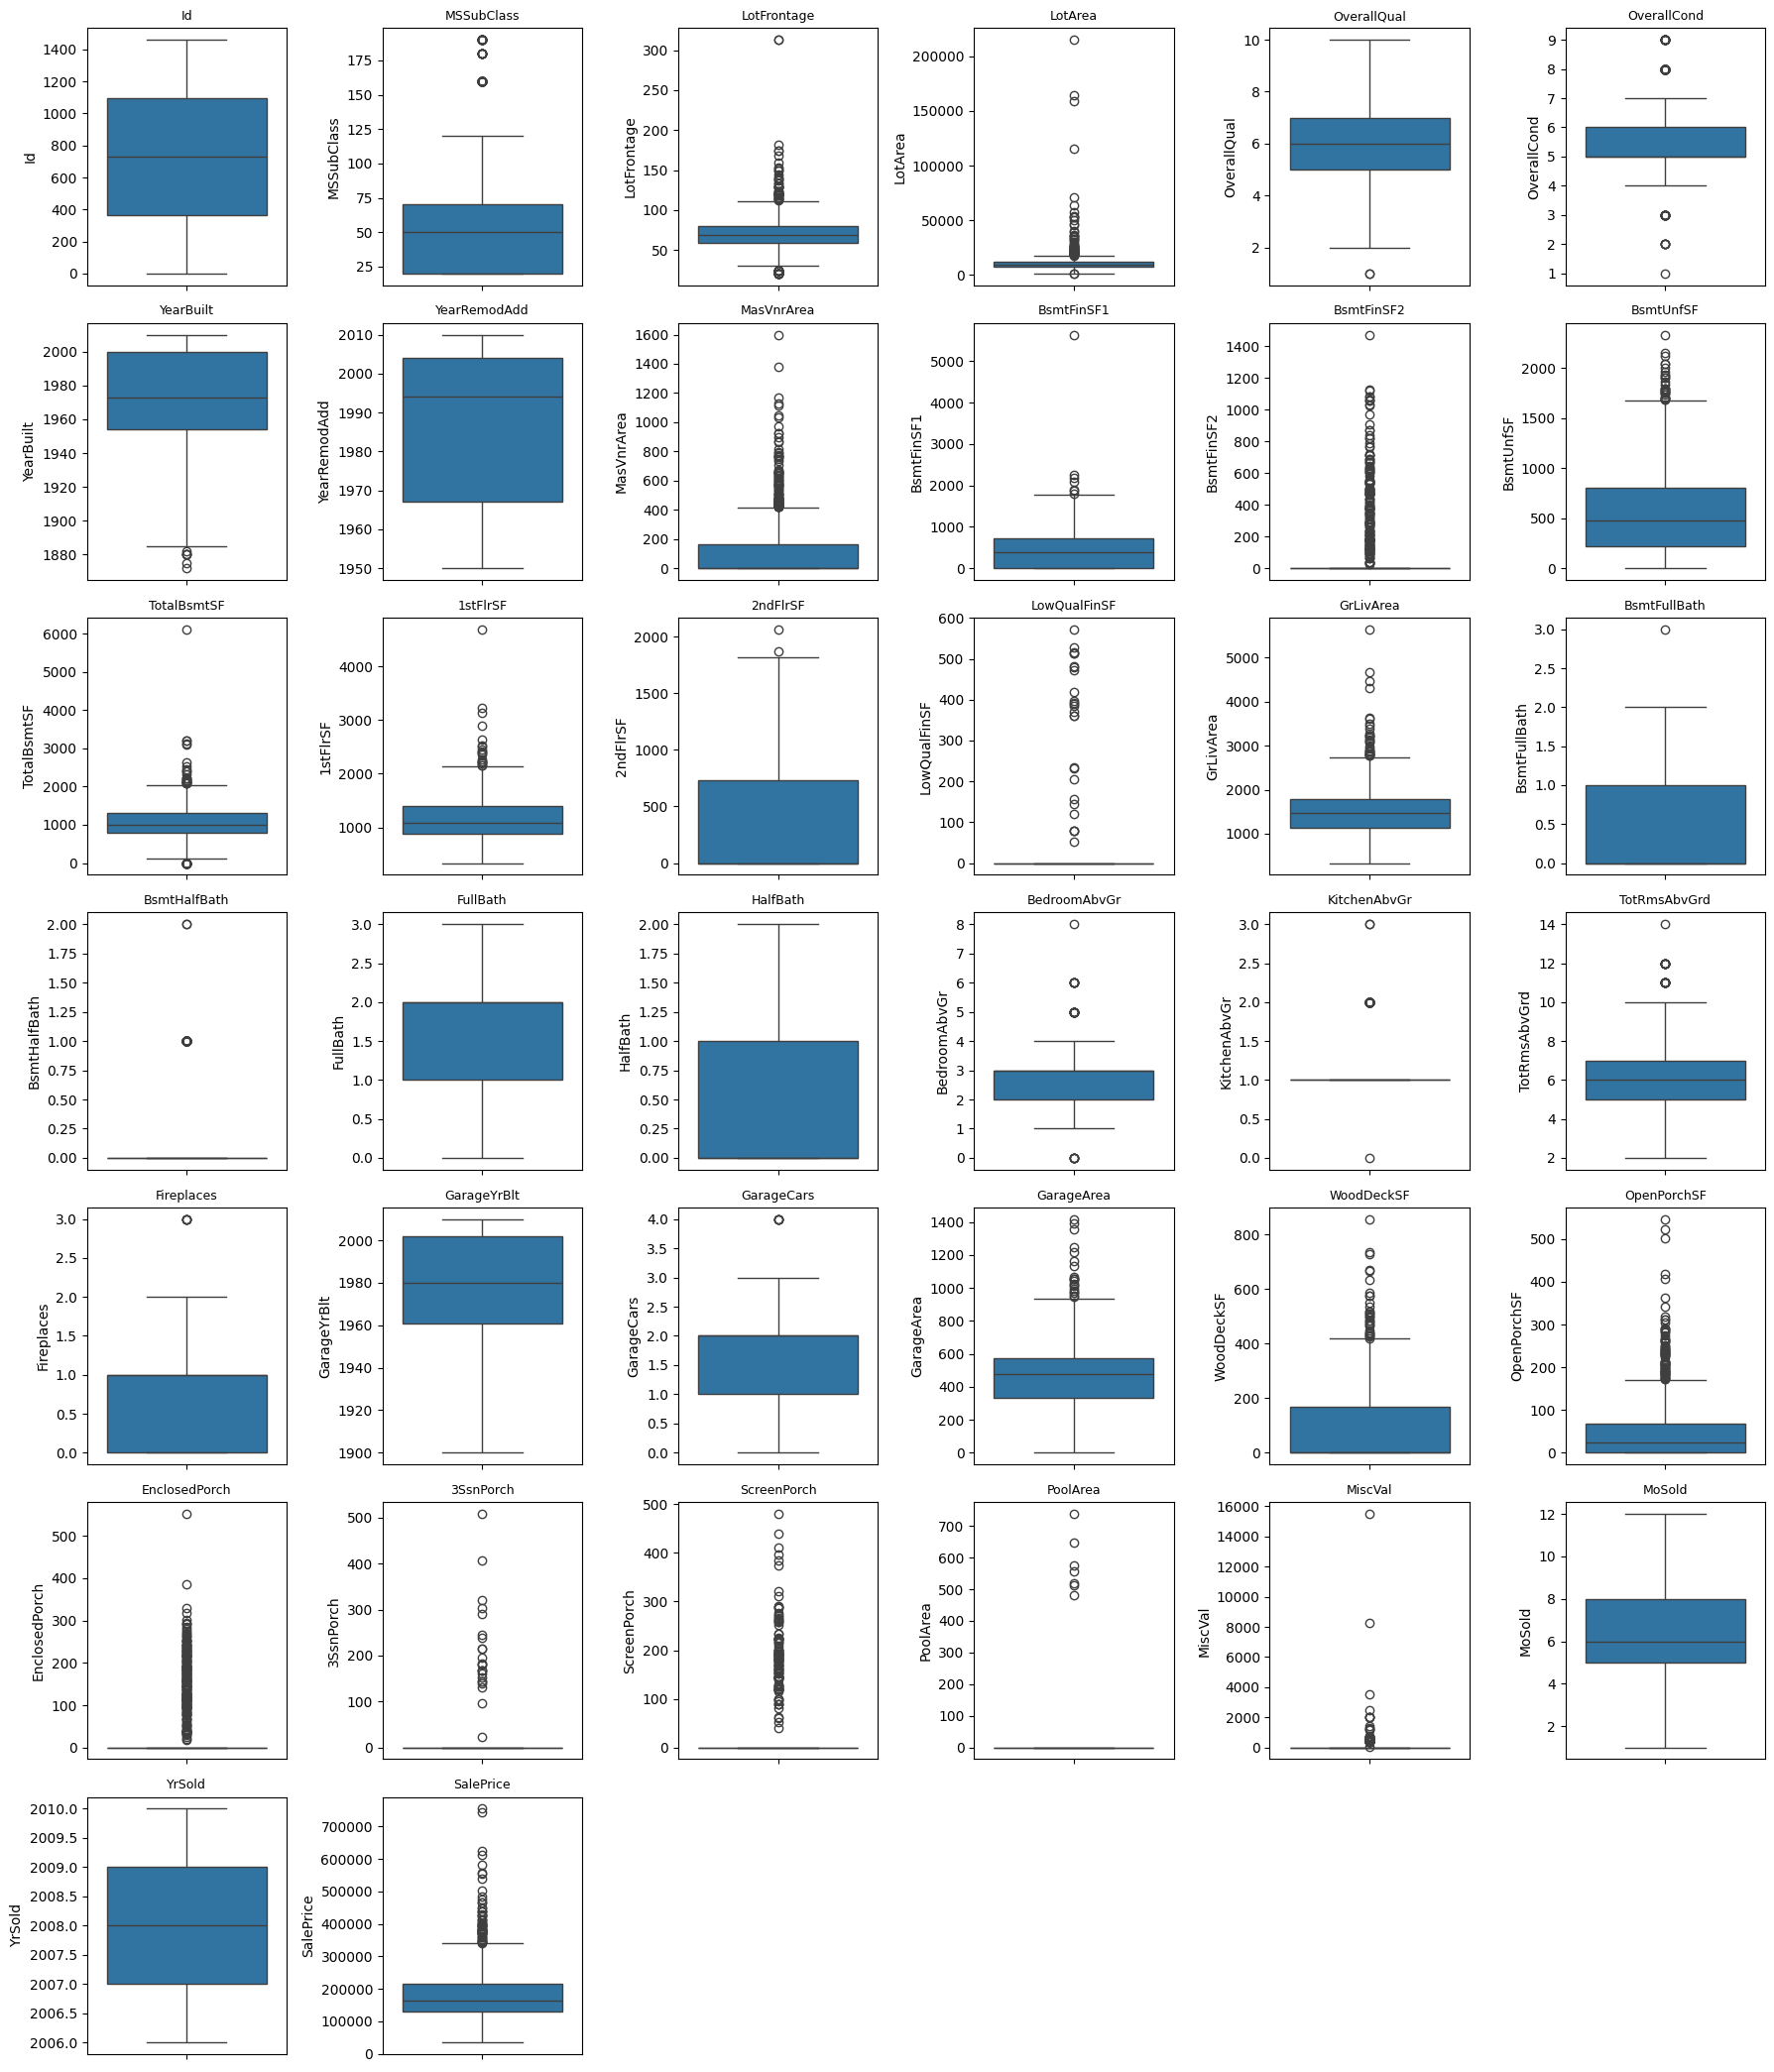

In [57]:
import math

# 1. Select numeric columns
numeric_cols = train_data.select_dtypes(include=['int64', 'float64']).columns
n_cols = len(numeric_cols)

# 2. Calculate optimal grid size
n_rows = math.ceil(n_cols / 6)  # Keep 6 columns, adjust rows as needed
plt.figure(figsize=(18, 3*n_rows))  # Adjust height based on rows

# 3. Create boxplots
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, 6, i)  # Dynamic grid
    sns.boxplot(y=train_data[col])
    plt.title(col, fontsize=9)
    plt.tight_layout()

plt.show()

In [58]:
corr_matrix = train_data[numeric_cols].corr()
LotArea_corr = corr_matrix[['LotArea']].sort_values(by='LotArea', ascending=False)

print(LotArea_corr)

                LotArea
LotArea        1.000000
LotFrontage    0.426095
1stFlrSF       0.299475
Fireplaces     0.271364
SalePrice      0.263843
GrLivArea      0.263116
TotalBsmtSF    0.260833
BsmtFinSF1     0.214103
TotRmsAbvGrd   0.190015
GarageArea     0.180403
WoodDeckSF     0.171698
BsmtFullBath   0.158155
GarageCars     0.154871
FullBath       0.126031
BedroomAbvGr   0.119690
BsmtFinSF2     0.111170
OverallQual    0.105806
MasVnrArea     0.104160
OpenPorchSF    0.084774
PoolArea       0.077672
2ndFlrSF       0.050986
BsmtHalfBath   0.048046
ScreenPorch    0.043160
MiscVal        0.038068
3SsnPorch      0.020423
HalfBath       0.014259
YearBuilt      0.014228
YearRemodAdd   0.013788
LowQualFinSF   0.004779
MoSold         0.001205
BsmtUnfSF     -0.002618
OverallCond   -0.005636
YrSold        -0.014261
KitchenAbvGr  -0.017784
EnclosedPorch -0.018340
GarageYrBlt   -0.024947
Id            -0.033226
MSSubClass    -0.139781


In [59]:
LotFrontage_corr = corr_matrix[['LotFrontage']].sort_values(by='LotFrontage', ascending=False)

print(LotFrontage_corr)

               LotFrontage
LotFrontage       1.000000
1stFlrSF          0.457181
LotArea           0.426095
GrLivArea         0.402797
TotalBsmtSF       0.392075
TotRmsAbvGrd      0.352096
SalePrice         0.351799
GarageArea        0.344997
GarageCars        0.285691
Fireplaces        0.266639
BedroomAbvGr      0.263170
OverallQual       0.251646
BsmtFinSF1        0.233633
PoolArea          0.206167
FullBath          0.198769
MasVnrArea        0.193458
OpenPorchSF       0.151972
BsmtUnfSF         0.132644
YearBuilt         0.123349
BsmtFullBath      0.100949
YearRemodAdd      0.088866
WoodDeckSF        0.088521
2ndFlrSF          0.080177
GarageYrBlt       0.070250
3SsnPorch         0.070029
HalfBath          0.053532
BsmtFinSF2        0.049900
ScreenPorch       0.041383
LowQualFinSF      0.038469
MoSold            0.011200
EnclosedPorch     0.010700
YrSold            0.007450
MiscVal           0.003368
KitchenAbvGr     -0.006069
BsmtHalfBath     -0.007234
Id               -0.010601
O

In [60]:
train_data = train_data.drop(train_data[(train_data['GrLivArea'] > 4000) & (train_data['SalePrice'] < 300000)].index)
train_data=train_data.drop(train_data[(train_data["LotArea"] >100000)].index)
train_data=train_data.drop(train_data[(train_data['LotFrontage']>300)].index)

In [61]:
corr_matrix = train_data[numeric_cols].corr()
LotArea_corr = corr_matrix[['LotArea']].sort_values(by='LotArea', ascending=False)

print(LotArea_corr)
#Co cai thien do anh huong cua LotArea

                LotArea
LotArea        1.000000
LotFrontage    0.483067
SalePrice      0.371234
1stFlrSF       0.364712
GrLivArea      0.354536
Fireplaces     0.309319
TotRmsAbvGrd   0.294628
TotalBsmtSF    0.286988
GarageArea     0.279522
GarageCars     0.253814
WoodDeckSF     0.225174
BsmtFinSF1     0.201121
BedroomAbvGr   0.197668
OverallQual    0.156748
FullBath       0.155303
OpenPorchSF    0.131908
BsmtFullBath   0.128763
MasVnrArea     0.125370
ScreenPorch    0.104603
2ndFlrSF       0.100962
BsmtFinSF2     0.082293
HalfBath       0.074666
PoolArea       0.071879
3SsnPorch      0.048441
BsmtUnfSF      0.042250
YearBuilt      0.032329
BsmtHalfBath   0.031751
MiscVal        0.031688
YearRemodAdd   0.024798
LowQualFinSF   0.019803
MoSold         0.001389
EnclosedPorch -0.001282
Id            -0.003473
GarageYrBlt   -0.011269
KitchenAbvGr  -0.013713
OverallCond   -0.019186
YrSold        -0.031520
MSSubClass    -0.283453


In [62]:
LotFrontage_corr = corr_matrix[['LotFrontage']].sort_values(by='LotFrontage', ascending=False)

print(LotFrontage_corr)
#Cos cai thien do anh huong cua LotFrontage

               LotFrontage
LotFrontage       1.000000
LotArea           0.483067
1stFlrSF          0.401121
SalePrice         0.378078
GrLivArea         0.361978
TotalBsmtSF       0.344198
GarageArea        0.338737
TotRmsAbvGrd      0.338297
GarageCars        0.305955
BedroomAbvGr      0.275692
Fireplaces        0.246418
OverallQual       0.240620
FullBath          0.197541
MasVnrArea        0.179923
BsmtUnfSF         0.160147
BsmtFinSF1        0.149529
OpenPorchSF       0.132107
YearBuilt         0.126582
PoolArea          0.123528
WoodDeckSF        0.095247
3SsnPorch         0.079988
2ndFlrSF          0.079645
YearRemodAdd      0.079361
GarageYrBlt       0.073122
BsmtFullBath      0.061354
HalfBath          0.053813
ScreenPorch       0.052137
BsmtFinSF2        0.046069
LowQualFinSF      0.045589
EnclosedPorch     0.020610
MoSold            0.012044
MiscVal           0.006921
YrSold            0.004134
KitchenAbvGr     -0.001417
BsmtHalfBath     -0.002479
Id               -0.024755
O

In [63]:
train_data=train_data.drop(['PoolQC','MiscFeature','Alley','Fence','MasVnrType'],axis=1)
test_data=test_data.drop(['PoolQC','MiscFeature','Alley','Fence','MasVnrType'],axis=1)

In [64]:
columns_None = ['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','GarageType','GarageFinish','GarageQual','FireplaceQu','GarageCond']
train_data[columns_None]= train_data[columns_None].fillna('None')
test_data[columns_None]= test_data[columns_None].fillna('None')

In [65]:
columns_with_lownullvalues = ['MSZoning','Utilities','Exterior1st','Exterior2nd','Electrical','KitchenQual','Functional','SaleType']

test_data[columns_with_lownullvalues] = test_data[columns_with_lownullvalues].fillna(test_data.mode().iloc[0])
train_data[columns_with_lownullvalues] = train_data[columns_with_lownullvalues].fillna(train_data.mode().iloc[0])

In [66]:

NUll_val = test_data.isnull().sum().sort_values(ascending=False)
NUll_val.head(20)

LotFrontage     227
GarageYrBlt      78
MasVnrArea       15
BsmtFullBath      2
BsmtHalfBath      2
TotalBsmtSF       1
BsmtUnfSF         1
BsmtFinSF2        1
BsmtFinSF1        1
GarageCars        1
GarageArea        1
Id                0
KitchenQual       0
TotRmsAbvGrd      0
FullBath          0
KitchenAbvGr      0
BedroomAbvGr      0
HalfBath          0
Fireplaces        0
GrLivArea         0
dtype: int64

In [67]:
NUll_val = train_data.isnull().sum().sort_values(ascending=False)
NUll_val.head(20)

LotFrontage     256
GarageYrBlt      81
MasVnrArea        8
Id                0
BedroomAbvGr      0
FireplaceQu       0
Fireplaces        0
Functional        0
TotRmsAbvGrd      0
KitchenQual       0
KitchenAbvGr      0
HalfBath          0
FullBath          0
BsmtHalfBath      0
BsmtFullBath      0
GrLivArea         0
LowQualFinSF      0
2ndFlrSF          0
1stFlrSF          0
GarageType        0
dtype: int64

In [68]:
train_data['GarageYrBlt'] = train_data['GarageYrBlt'].fillna(train_data['YrSold']-35)
test_data['GarageYrBlt'] = test_data['GarageYrBlt'].fillna(test_data['YrSold']-35)
train_data['LotFrontage'] = train_data['LotFrontage'].fillna(68)
test_data['LotFrontage'] = test_data['LotFrontage'].fillna(68)

In [69]:
NUll_val = train_data.isnull().sum().sort_values(ascending=False)
NUll_val.head(5)

MasVnrArea      8
Id              0
BedroomAbvGr    0
FireplaceQu     0
Fireplaces      0
dtype: int64

In [70]:

NUll_val = test_data.isnull().sum().sort_values(ascending=False)
NUll_val.head(10)

MasVnrArea      15
BsmtHalfBath     2
BsmtFullBath     2
TotalBsmtSF      1
BsmtUnfSF        1
BsmtFinSF2       1
BsmtFinSF1       1
GarageCars       1
GarageArea       1
BedroomAbvGr     0
dtype: int64

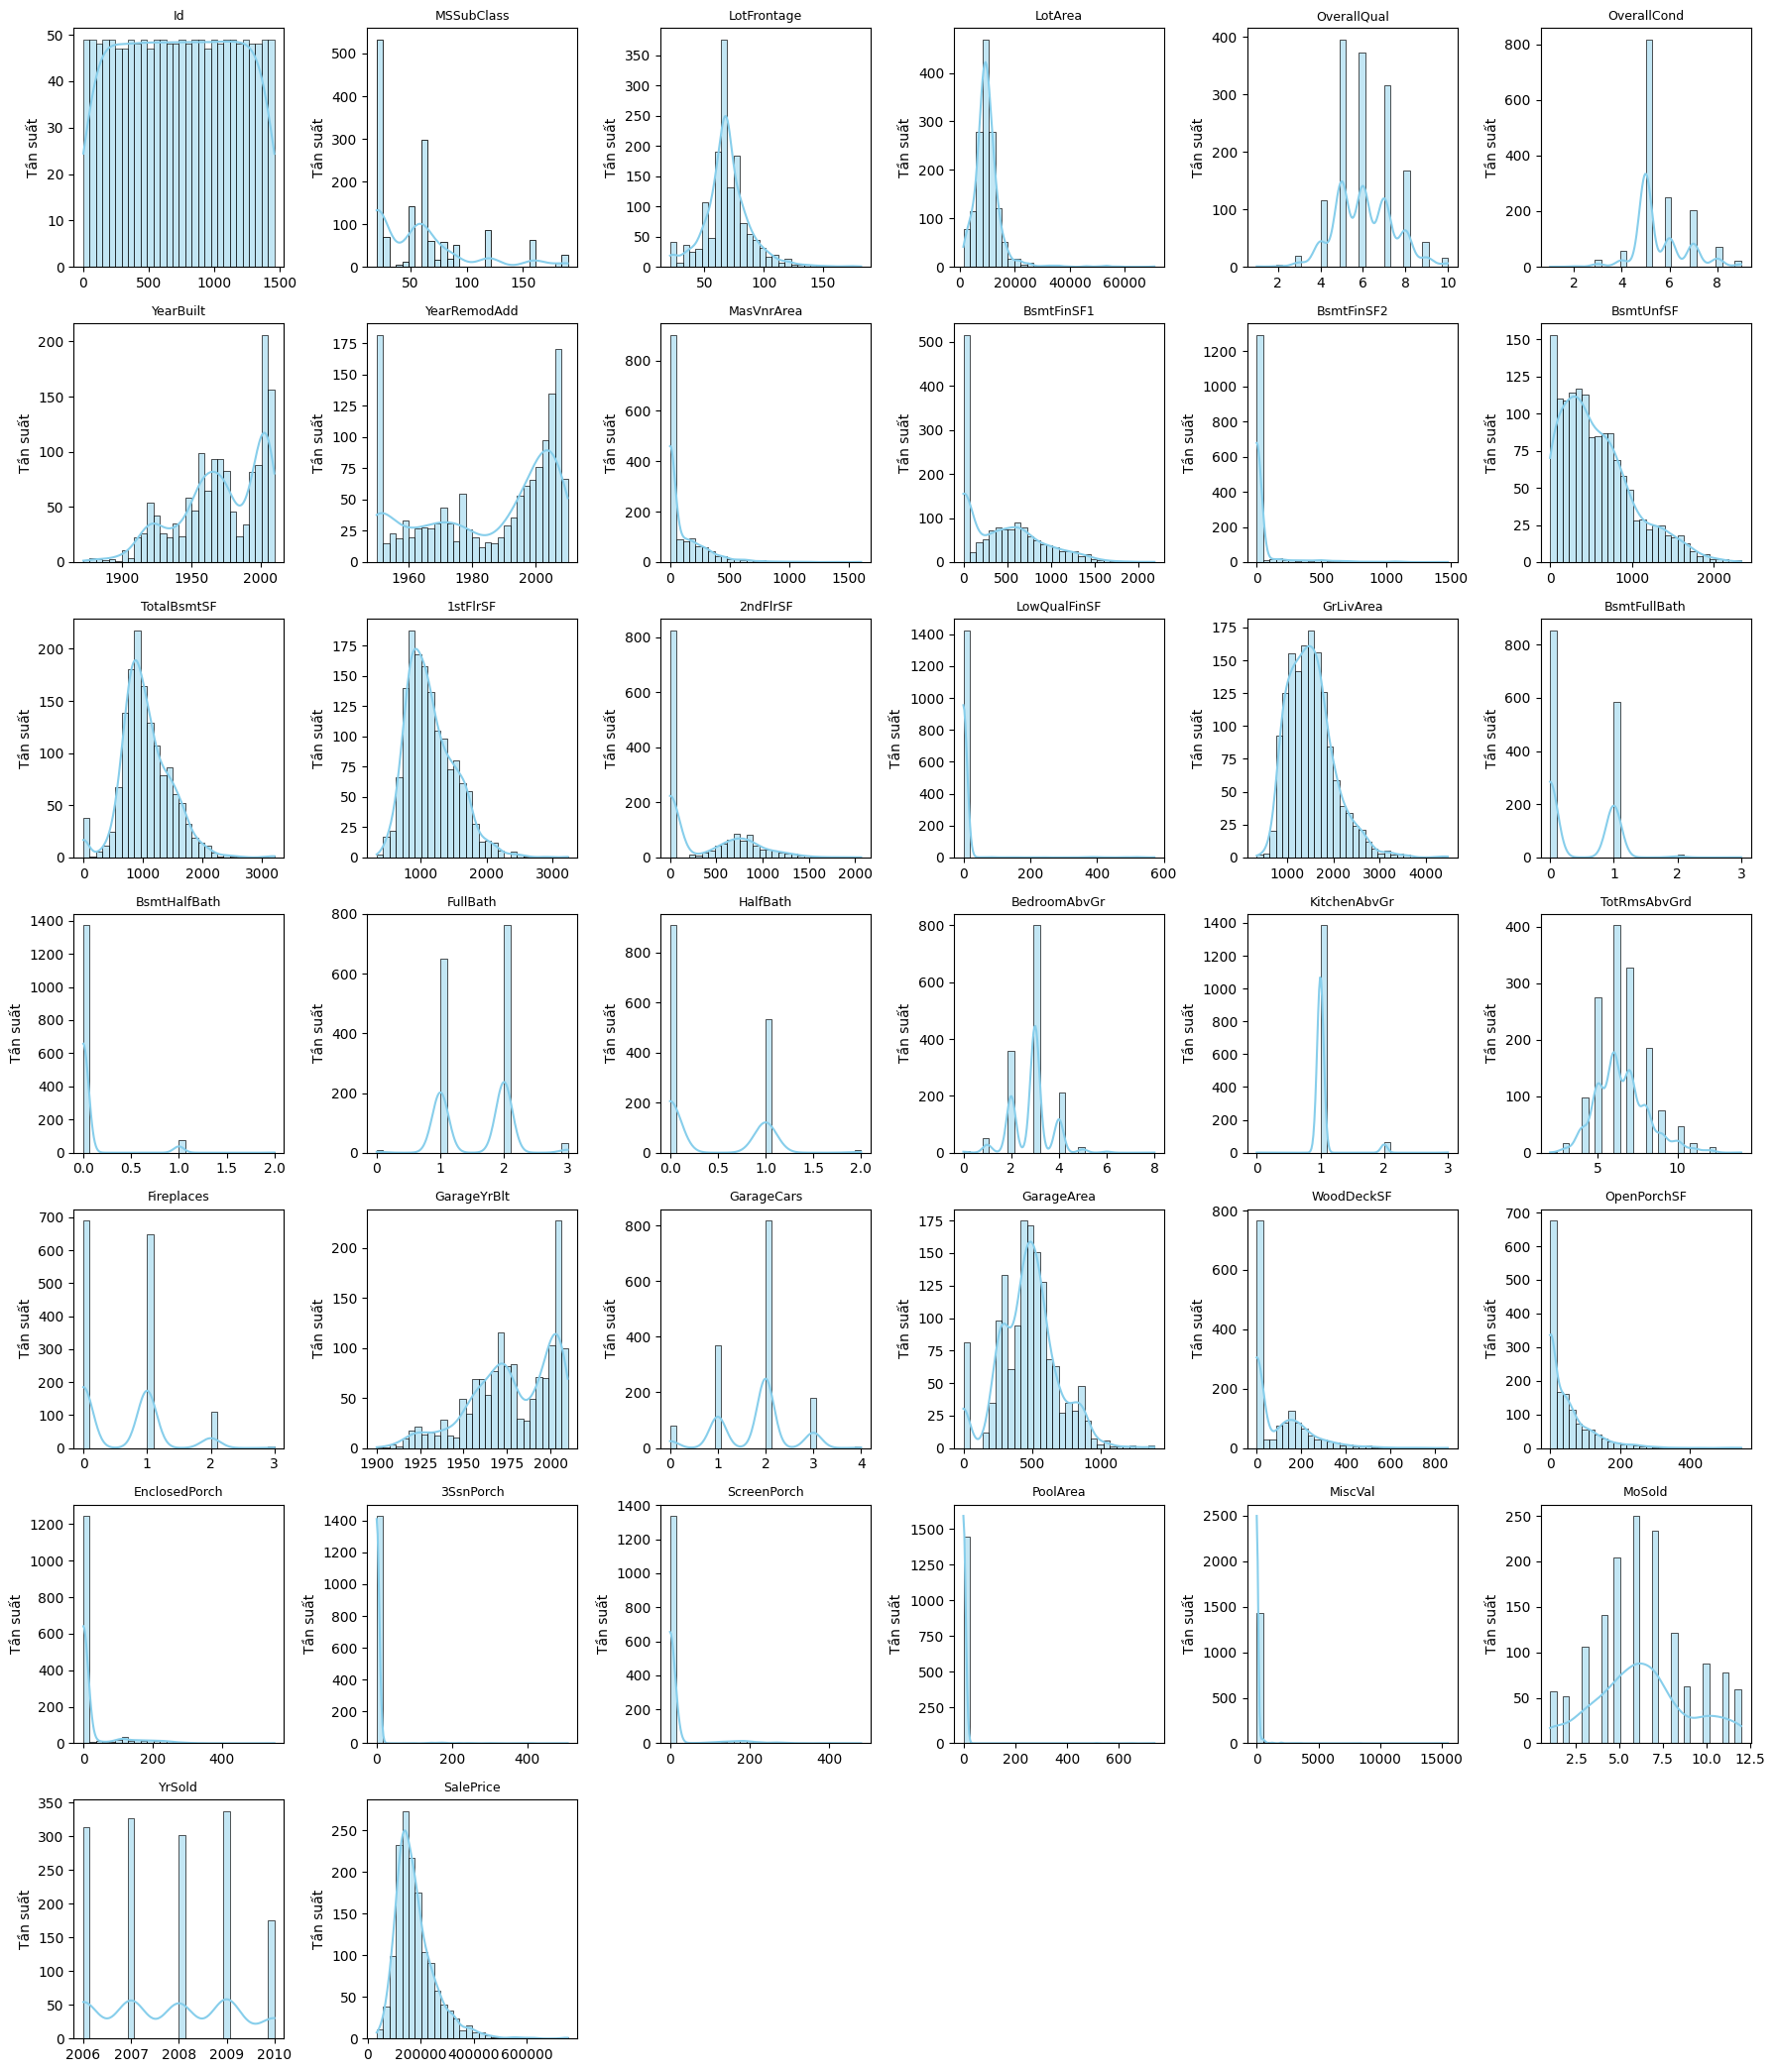

In [71]:

numeric_cols = train_data.select_dtypes(include=['int64', 'float64']).columns
n_cols = len(numeric_cols)

n_rows = math.ceil(n_cols / 6)
plt.figure(figsize=(18, 3 * n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, 6, i)
    sns.histplot(train_data[col], kde=True, bins=30, color='skyblue')
    plt.title(col, fontsize=9)
    plt.xlabel('')
    plt.ylabel('Tần suất')
    plt.tight_layout()

plt.show()

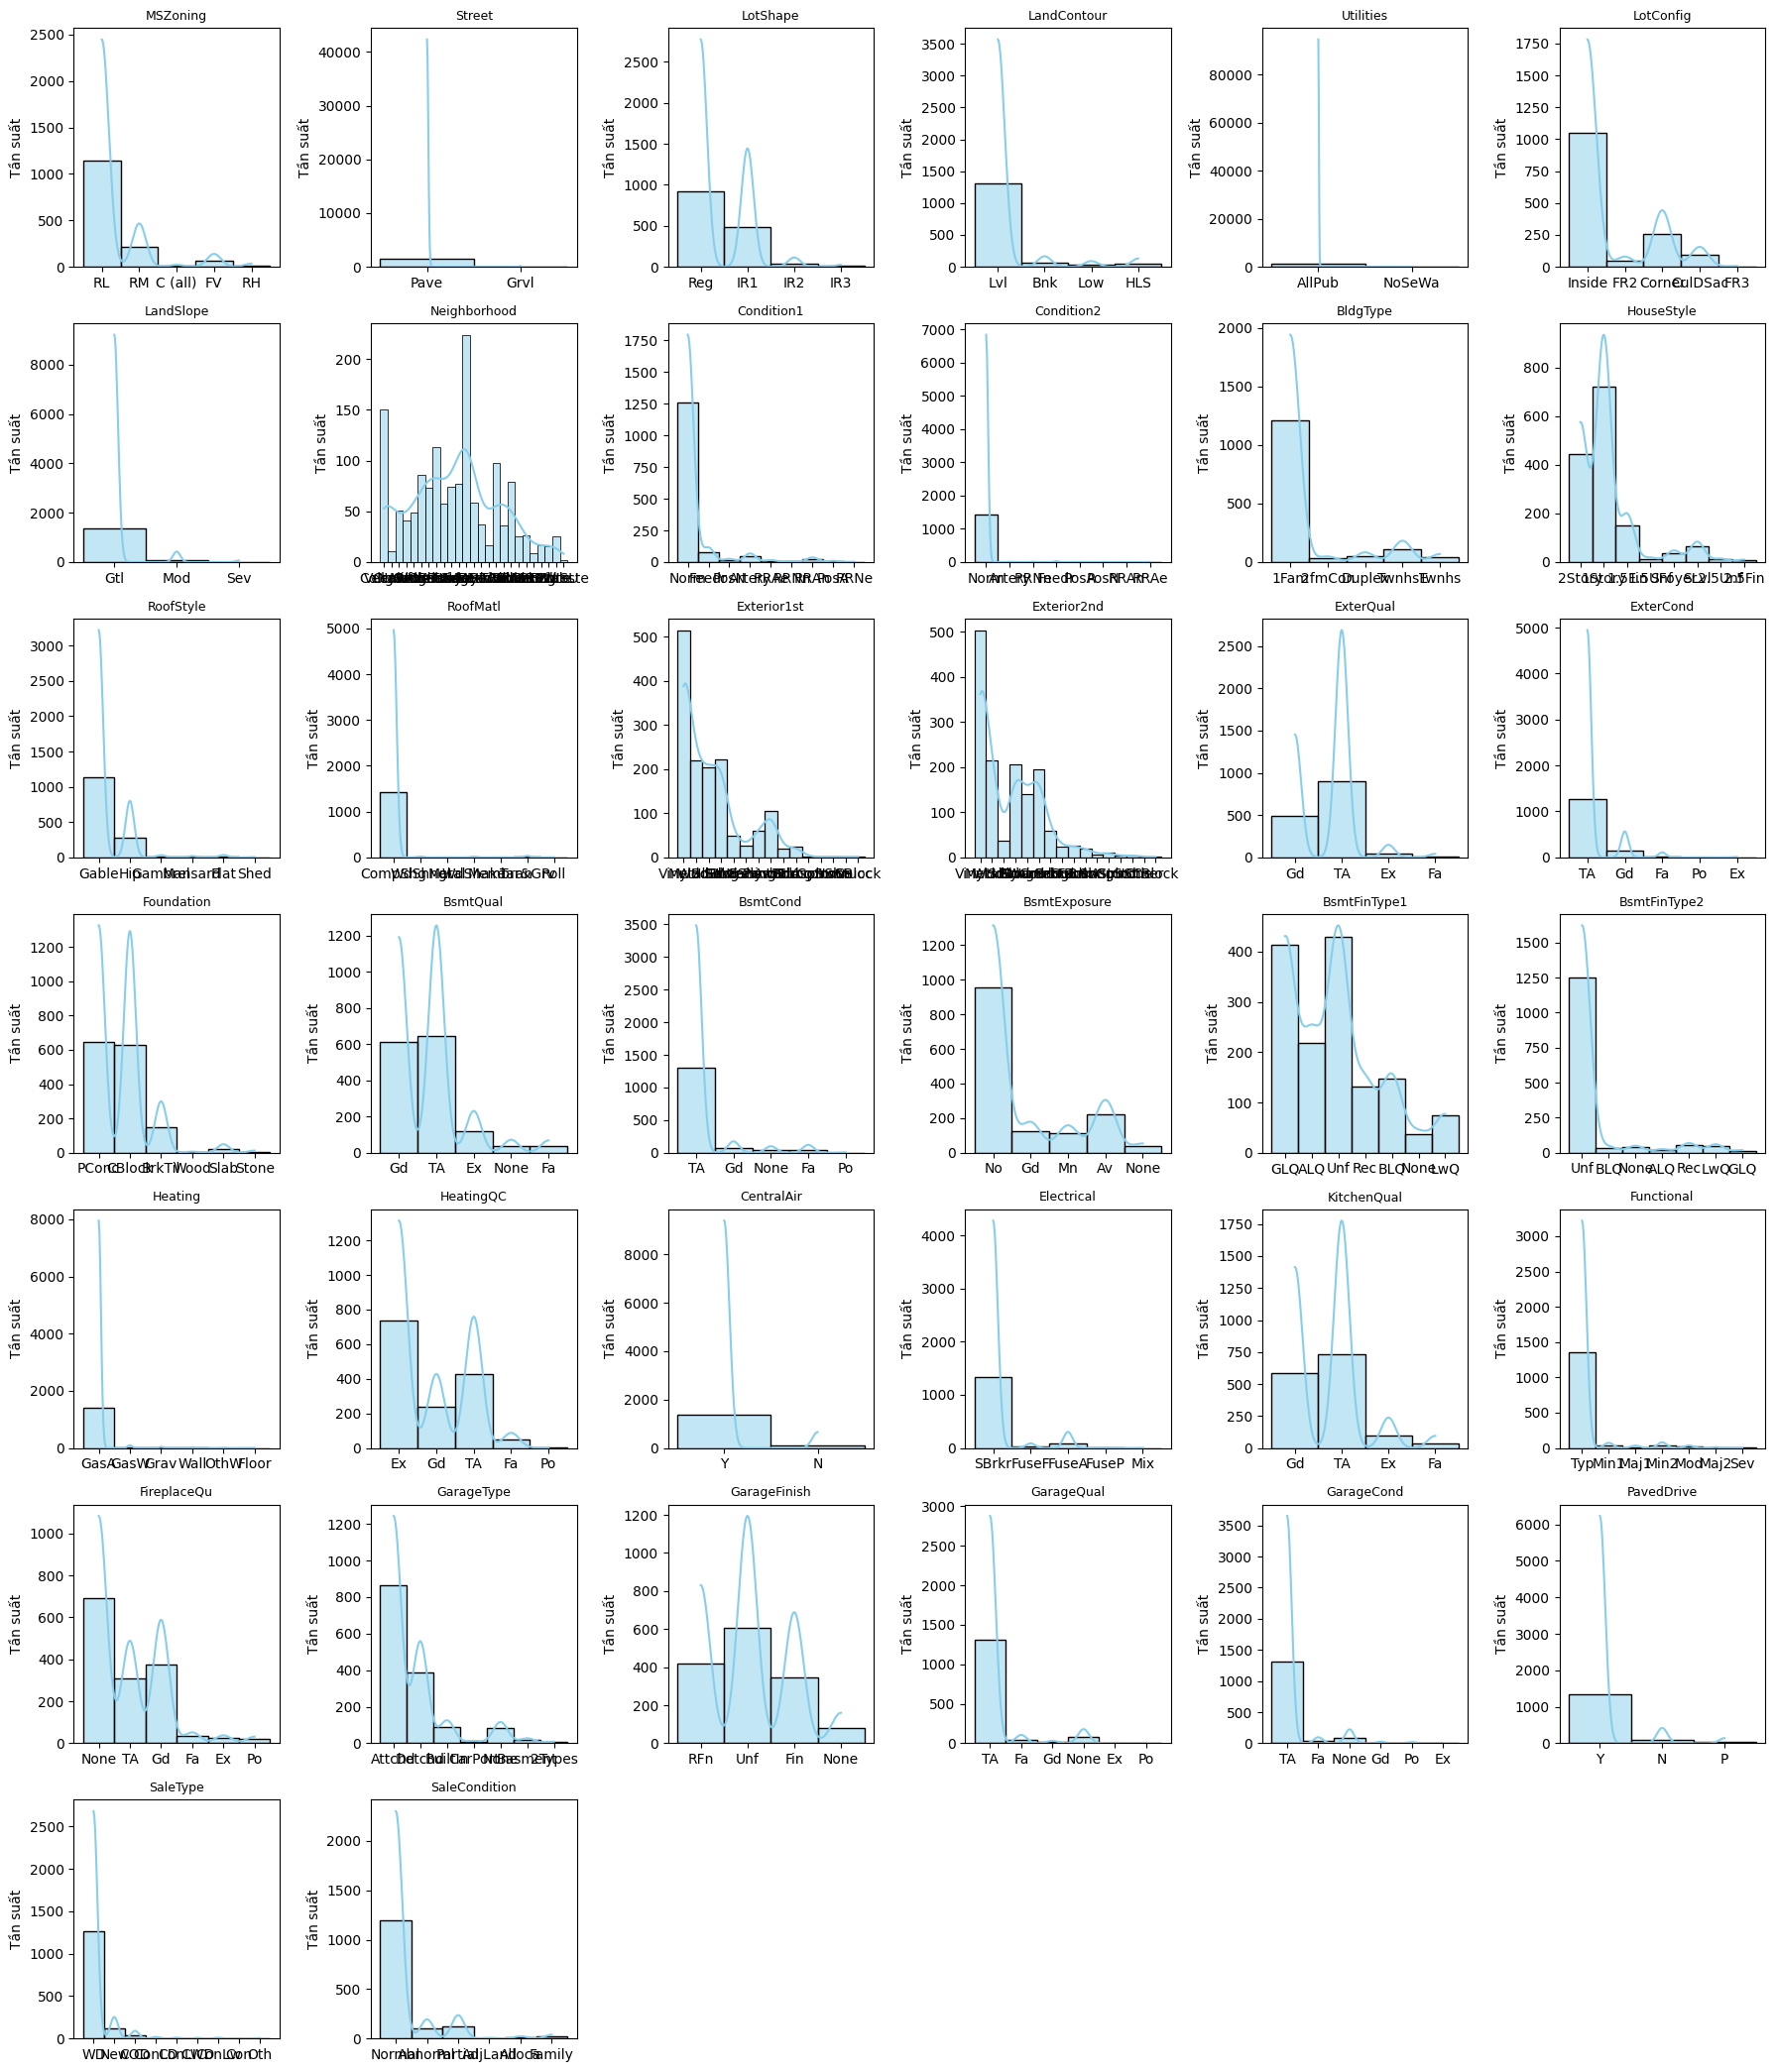

In [72]:
# 1. Lấy các cột số
cat_cols = train_data.select_dtypes(include=['object']).columns
n_cols = len(numeric_cols)

# 2. Tính số hàng của grid
n_rows = math.ceil(n_cols / 6)
plt.figure(figsize=(18, 3 * n_rows))

# 3. Vẽ histogram (phân phối tần suất)
for i, col in enumerate(cat_cols, 1):
    plt.subplot(n_rows, 6, i)
    sns.histplot(train_data[col], kde=True, bins=30, color='skyblue')
    plt.title(col, fontsize=9)
    plt.xlabel('')
    plt.ylabel('Tần suất')
    plt.tight_layout()

plt.show()

In [73]:
train_data = train_data.drop(['Heating','RoofMatl','Condition2','Street','Utilities'],axis=1)
test_data = test_data.drop(['Heating','RoofMatl','Condition2','Street','Utilities'],axis=1)

In [74]:
train_data["SalePrice"] = np.log1p(train_data["SalePrice"])
train_data["TotalSF"] = train_data["TotalBsmtSF"] + train_data["1stFlrSF"] + train_data["2ndFlrSF"]
test_data["TotalSF"] = test_data["TotalBsmtSF"] + test_data["1stFlrSF"] + test_data["2ndFlrSF"]

train_data["HouseAge"] = train_data["YrSold"] - train_data["YearBuilt"]
test_data["HouseAge"] = test_data["YrSold"] - test_data["YearBuilt"]

train_data["QualCond"] = train_data["OverallQual"]*train_data["OverallCond"]
test_data["QualCond"] = test_data["OverallQual"]*test_data["OverallCond"]

In [75]:
target = "SalePrice"
numerical_features = train_data.select_dtypes(include=['float64', 'int64']).columns
categorical_features = train_data.select_dtypes(include='object').columns
num_features = [col for col in numerical_features if col != target]

# Fill missing
train_data[categorical_features] = train_data[categorical_features].fillna("Missing")
test_data[categorical_features] = test_data[categorical_features].fillna("Missing")
train_data[num_features] = train_data[num_features].fillna(0)
test_data[num_features] = test_data[num_features].fillna(0)

# Đồng nhất categories giữa train và test
for col in categorical_features:
    all_values = pd.concat([train_data[col], test_data[col]], axis=0).astype(str).unique()
    train_data[col] = pd.Categorical(train_data[col].astype(str), categories=all_values)
    test_data[col] = pd.Categorical(test_data[col].astype(str), categories=all_values)

In [76]:
train = train_data.copy()
test = test_data.copy()

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Traceback (most recent call last):
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 356, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 454, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1595, in _read_yam


🚀 Start run: LightGBM_regression_best_163009
🔍 Đang tìm tham số tốt nhất cho LightGBM bằng Optuna (20 lần thử)...


Best trial: 0. Best value: -0.0211697:   5%|▌         | 1/20 [00:07<02:29,  7.88s/it]

[I 2025-10-28 16:30:17,441] Trial 0 finished with value: -0.02116973591754419 and parameters: {'n_estimators': 1661, 'learning_rate': 0.08422139922904301, 'max_depth': 9, 'num_leaves': 102, 'subsample': 0.5797063228594439, 'colsample_bytree': 0.8562879133277133, 'lambda_l1': 4.3388739653068754e-07, 'lambda_l2': 0.009251139015008979, 'min_child_samples': 70}. Best is trial 0 with value: -0.02116973591754419.


Best trial: 1. Best value: -0.020956:  10%|█         | 2/20 [00:13<02:00,  6.72s/it] 

...

[I 2025-10-28 16:30:56,998] Trial 17 finished with value: -0.016080047965306748 and parameters: {'n_estimators': 1371, 'learning_rate': 0.015487889276759103, 'max_depth': 4, 'num_leaves': 44, 'subsample': 0.6582739406110772, 'colsample_bytree': 0.686996900149156, 'lambda_l1': 5.96746229127586e-07, 'lambda_l2': 1.1607660791262016e-08, 'min_child_samples': 31}. Best is trial 17 with value: -0.016080047965306748.


Best trial: 17. Best value: -0.01608:  95%|█████████▌| 19/20 [00:48<00:01,  1.54s/it]

[I 2025-10-28 16:30:57,685] Trial 18 finished with value: -0.016311594247252332 and parameters: {'n_estimators': 925, 'learning_rate': 0.015297931114815809, 'max_depth': 3, 'num_leaves': 42, 'subsample': 0.7807509891712119, 'colsample_bytree': 0.8921327416515852, 'lambda_l1': 1.3129024738298772e-07, 'lambda_l2': 2.552300006136871e-07, 'min_child_samples': 29}. Best is trial 17 with value: -0.016080047965306748.


Best trial: 17. Best value: -0.01608: 100%|██████████| 20/20 [00:49<00:00,  2.48s/it]


[I 2025-10-28 16:30:59,210] Trial 19 finished with value: -0.016186183374483788 and parameters: {'n_estimators': 1631, 'learning_rate': 0.015828420666274115, 'max_depth': 4, 'num_leaves': 98, 'subsample': 0.7005313546843868, 'colsample_bytree': 0.6489341131909044, 'lambda_l1': 5.548404541004863e-06, 'lambda_l2': 1.1687930502670637e-06, 'min_child_samples': 46}. Best is trial 17 with value: -0.016080047965306748.
✅ Best params (Optuna): {'n_estimators': 1371, 'learning_rate': 0.015487889276759103, 'max_depth': 4, 'num_leaves': 44, 'subsample': 0.6582739406110772, 'colsample_bytree': 0.686996900149156, 'lambda_l1': 5.96746229127586e-07, 'lambda_l2': 1.1607660791262016e-08, 'min_child_samples': 31}
🎯 Best params sau tuning: {'n_estimators': 1371, 'learning_rate': 0.015487889276759103, 'max_depth': 4, 'num_leaves': 44, 'subsample': 0.6582739406110772, 'colsample_bytree': 0.686996900149156, 'lambda_l1': 5.96746229127586e-07, 'lambda_l2': 1.1607660791262016e-08, 'min_child_samples': 31}
✅ Fi

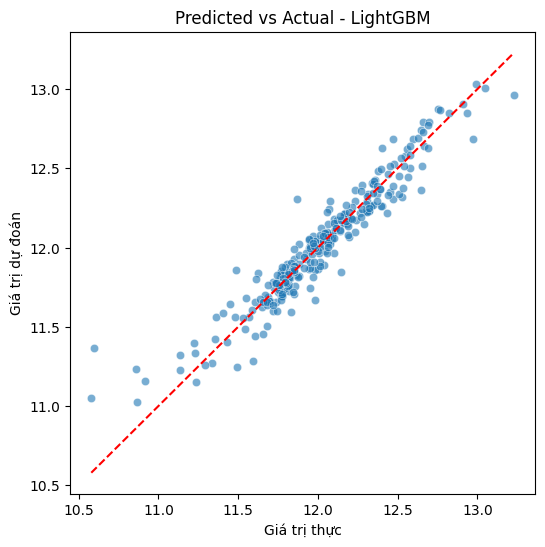

D:\Kaggle\Team_SGU_25_ML_Fundamental\Challenge\2_HousePrices\src\evaluation\Evaluation.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=imp_df, palette="viridis")


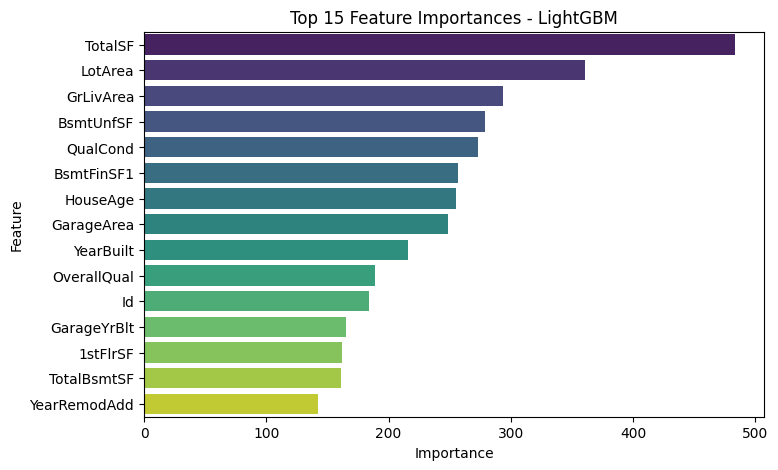

2025/10/28 16:31:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Đã chạy đánh giá đầy đủ cho task: regression.
✅ Mô hình đã lưu local: experiments/models\LightGBM_regression_best_163009_20251028_163102_model.pkl


2025/10/28 16:31:10 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Dữ liệu đã lưu local: experiments/data/processed\LightGBM_regression_best_163009_20251028_163110_data.csv


In [77]:
from pipeline.LightGBMPipline import LightGBMPipeline

pipeline = LightGBMPipeline(experiment_name="version3")
pipeline.run(
    df=train,
    target_col=target,
    task="regression",
    model_name="LightGBM",
    backend="mlflow"
)

Traceback (most recent call last):
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 356, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 454, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1595, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1588, in _read


🚀 Start run: XGBoost_regression_best_163110
🔍 Đang tìm tham số tốt nhất cho XGBoost bằng Optuna (20 lần thử)...


Best trial: 0. Best value: -0.0161761:   5%|▌         | 1/20 [00:01<00:27,  1.45s/it]

[I 2025-10-28 16:31:12,346] Trial 0 finished with value: -0.01617606905180678 and parameters: {'n_estimators': 974, 'learning_rate': 0.06005843614077158, 'max_depth': 6, 'subsample': 0.6946703875002535, 'colsample_bytree': 0.6168654619506533, 'reg_alpha': 1.4570155506386218e-06, 'reg_lambda': 7.576441526517939e-08, 'min_child_weight': 2, 'gamma': 3.525775729670819e-05}. Best is trial 0 with value: -0.01617606905180678.


Best trial: 1. Best value: -0.0147963:  10%|█         | 2/20 [00:02<00:20,  1.14s/it]

...

Best trial: 16. Best value: -0.0142936:  95%|█████████▌| 19/20 [00:23<00:00,  1.23it/s]

[I 2025-10-28 16:31:34,671] Trial 18 finished with value: -0.01479982615707961 and parameters: {'n_estimators': 755, 'learning_rate': 0.010007506654195988, 'max_depth': 3, 'subsample': 0.667965851465166, 'colsample_bytree': 0.8357262686868451, 'reg_alpha': 0.0019007317328395112, 'reg_lambda': 0.0001110274552683135, 'min_child_weight': 6, 'gamma': 1.295761203203962e-06}. Best is trial 16 with value: -0.014293618153855207.


Best trial: 16. Best value: -0.0142936: 100%|██████████| 20/20 [00:24<00:00,  1.23s/it]

[I 2025-10-28 16:31:35,501] Trial 19 finished with value: -0.023982112040903825 and parameters: {'n_estimators': 900, 'learning_rate': 0.01591073962180301, 'max_depth': 5, 'subsample': 0.5830833666383469, 'colsample_bytree': 0.7535769495517507, 'reg_alpha': 5.962179647638287, 'reg_lambda': 0.3962295721591508, 'min_child_weight': 4, 'gamma': 2.537422893537738e-06}. Best is trial 16 with value: -0.014293618153855207.
✅ Best params (Optuna): {'n_estimators': 1127, 'learning_rate': 0.0112934800108919, 'max_depth': 3, 'subsample': 0.5586822996948471, 'colsample_bytree': 0.8037100032657636, 'reg_alpha': 0.08941178425283035, 'reg_lambda': 1.0889024980927744e-05, 'min_child_weight': 6, 'gamma': 1.7222633328072724e-06, 'enable_categorical': True, 'random_state': 42}
🚀 Huấn luyện mô hình XGBoost với 1162 mẫu...
[0]	validation_0-rmse:0.38571


[200]	validation_0-rmse:0.14267
[400]	validation_0-rmse:0.11728
[600]	validation_0-rmse:0.11219
[800]	validation_0-rmse:0.11102
[1000]	validation_0-rmse:0.11038
[1126]	validation_0-rmse:0.11040

🔹 Evaluation Report for XGBoost (regression)

 Tổng hợp metrics:
        XGBoost
MAE    0.074114
RMSE   0.110397
RMSLE  0.008675
R²     0.919228


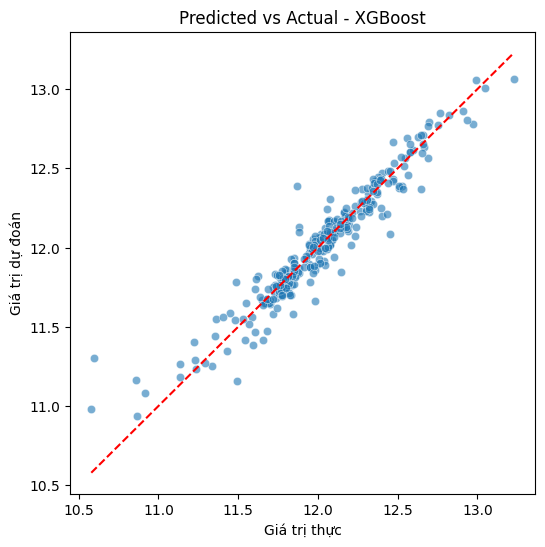

D:\Kaggle\Team_SGU_25_ML_Fundamental\Challenge\2_HousePrices\src\evaluation\Evaluation.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=imp_df, palette="viridis")


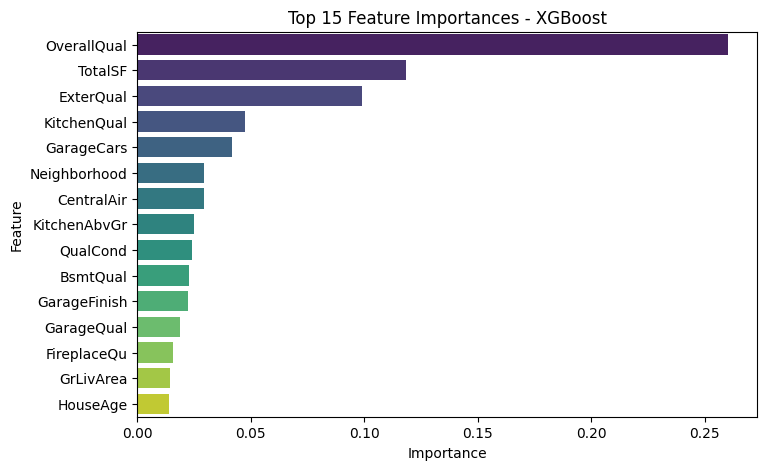

2025/10/28 16:31:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Mô hình đã lưu local: experiments/models\XGBoost_regression_best_163110_20251028_163137_model.pkl


2025/10/28 16:31:41 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Dữ liệu đã lưu local: experiments/data/processed\XGBoost_regression_best_163110_20251028_163141_data.csv


In [78]:
from pipeline.XGBoostPipeline import XGBoostPipeline
pipeline = XGBoostPipeline(experiment_name="version3")
pipeline.run(
    df=train,
    target_col=target,
    task="regression",
    model_name="XGBoost",
    backend="mlflow"
)

Traceback (most recent call last):
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 356, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 454, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1595, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1588, in _read


🚀 Start run: CatBoost_regression_best_163142
🔍 Phát hiện 33 cột phân loại: ['MSZoning', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']
🔍 Đang tìm tham số tốt nhất cho CatBoost bằng Optuna (20 lần thử)...


  0%|          | 0/20 [00:00<?, ?it/s]

[W 2025-10-28 16:31:42,537] Trial 0 failed with parameters: {'depth': 9, 'learning_rate': 0.015229661665384664, 'iterations': 1721, 'l2_leaf_reg': 1.8928967259599887, 'subsample': 0.5050725641575852, 'colsample_bylevel': 0.8426565671841661} because of the following error: TypeError("catboost.core.CatBoostRegressor() got multiple values for keyword argument 'random_seed'").
Traceback (most recent call last):
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "D:\Kaggle\Team_SGU_25_ML_Fundamental\Challenge\2_HousePrices\src\model\Catboost.py", line 105, in <lambda>
    study.optimize(lambda trial: self._objective_optuna(trial, X_train, y_train),
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\Kaggle\Team_SGU_25_ML_Fundamental\Challenge\2_HousePrices\src\model\Catboost.py", line 65, in _objectiv

0:	learn: 0.3873234	test: 0.3757556	best: 0.3757556 (0)	total: 214ms	remaining: 3m 33s
100:	learn: 0.1080340	test: 0.1224682	best: 0.1224682 (100)	total: 2.91s	remaining: 25.9s
200:	learn: 0.0888098	test: 0.1147157	best: 0.1146933 (199)	total: 5.57s	remaining: 22.1s
300:	learn: 0.0797607	test: 0.1128959	best: 0.1128959 (300)	total: 8.32s	remaining: 19.3s
400:	learn: 0.0719962	test: 0.1119005	best: 0.1119005 (400)	total: 11.1s	remaining: 16.6s
500:	learn: 0.0643161	test: 0.1111897	best: 0.1111897 (500)	total: 13.7s	remaining: 13.7s
600:	learn: 0.0579749	test: 0.1105987	best: 0.1105749 (597)	total: 16.5s	remaining: 10.9s
700:	learn: 0.0535710	test: 0.1101197	best: 0.1101197 (700)	total: 19.2s	remaining: 8.18s
800:	learn: 0.0492771	test: 0.1101191	best: 0.1099799 (741)	total: 21.9s	remaining: 5.44s
900:	learn: 0.0448502	test: 0.1103267	best: 0.1099799 (741)	total: 24.6s	remaining: 2.71s
999:	learn: 0.0414026	test: 0.1104379	best: 0.1099799 (741)	total: 27.3s	remaining: 0us

bestTest = 0.1

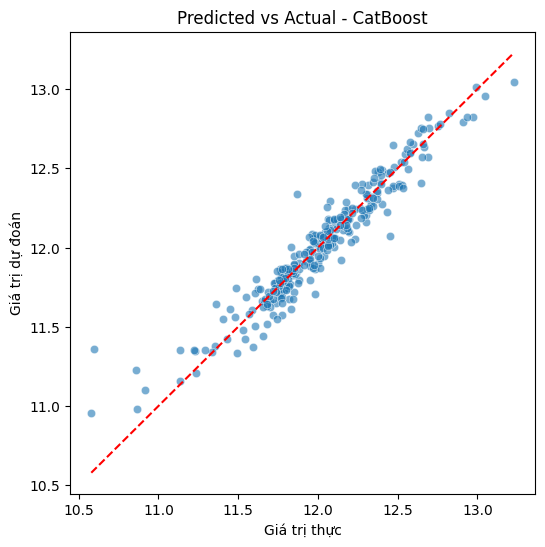

D:\Kaggle\Team_SGU_25_ML_Fundamental\Challenge\2_HousePrices\src\evaluation\Evaluation.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=imp_df, palette="viridis")


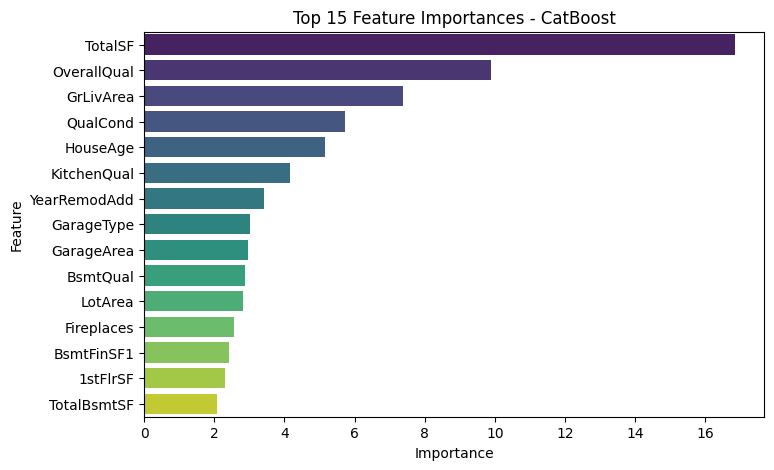

2025/10/28 16:32:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Mô hình đã lưu local: experiments/models\CatBoost_regression_best_163142_20251028_163210_model.pkl


2025/10/28 16:32:13 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Dữ liệu đã lưu local: experiments/data/processed\CatBoost_regression_best_163142_20251028_163214_data.csv


In [79]:
from pipeline.CatBoostPipeline import CatBoostPipeline
pipeline = CatBoostPipeline(experiment_name="version3")
pipeline.run(
    df=train,
    target_col=target,
    task="regression",
    model_name="CatBoost",
    backend="mlflow"
)

Traceback (most recent call last):
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 356, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 454, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1595, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1588, in _read


🚀 Start run: RandomForest_regression_best_163254
🔍 Đang tìm tham số tốt nhất cho Random Forest bằng Optuna (20 lần thử)...


Best trial: 0. Best value: -0.0191355:   5%|▌         | 1/20 [00:00<00:16,  1.18it/s]

[I 2025-10-28 16:32:55,158] Trial 0 finished with value: -0.019135492904517104 and parameters: {'n_estimators': 300, 'max_depth': 8, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_samples': 0.9144153921956355}. Best is trial 0 with value: -0.019135492904517104.


Best trial: 0. Best value: -0.0191355:  10%|█         | 2/20 [00:01<00:13,  1.29it/s]

...

[I 2025-10-28 16:33:07,730] Trial 17 finished with value: -0.019367077852179358 and parameters: {'n_estimators': 400, 'max_depth': 18, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_samples': 0.8276351936322901}. Best is trial 15 with value: -0.019110286097401123.


Best trial: 18. Best value: -0.0187122:  95%|█████████▌| 19/20 [00:13<00:00,  1.31it/s]

[I 2025-10-28 16:33:08,306] Trial 18 finished with value: -0.01871215261723166 and parameters: {'n_estimators': 200, 'max_depth': 16, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_samples': 0.9165436998244718}. Best is trial 18 with value: -0.01871215261723166.


Best trial: 18. Best value: -0.0187122: 100%|██████████| 20/20 [00:14<00:00,  1.40it/s]


[I 2025-10-28 16:33:08,609] Trial 19 finished with value: -0.02761552961984805 and parameters: {'n_estimators': 200, 'max_depth': 16, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'max_samples': 0.8783218388211728}. Best is trial 18 with value: -0.01871215261723166.
✅ Best params (Optuna): {'n_estimators': 200, 'max_depth': 16, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_samples': 0.9165436998244718, 'random_state': 42, 'n_jobs': -1}
🚀 Huấn luyện mô hình Random Forest...

🔹 Evaluation Report for RandomForest (regression)

 Tổng hợp metrics:
       RandomForest
MAE        0.083840
RMSE       0.123675
RMSLE      0.009751
R²         0.898630


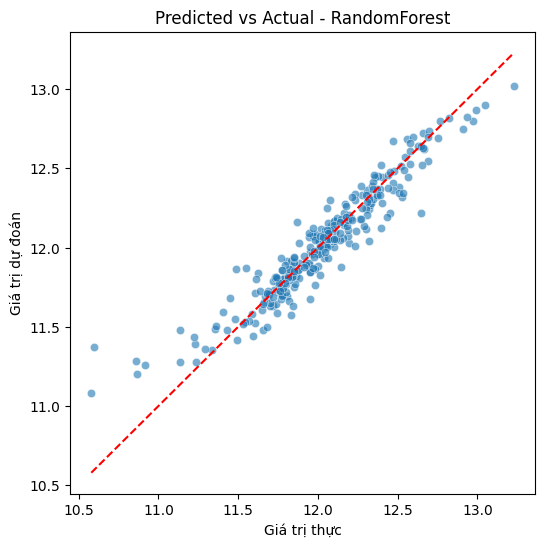

D:\Kaggle\Team_SGU_25_ML_Fundamental\Challenge\2_HousePrices\src\evaluation\Evaluation.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=imp_df, palette="viridis")


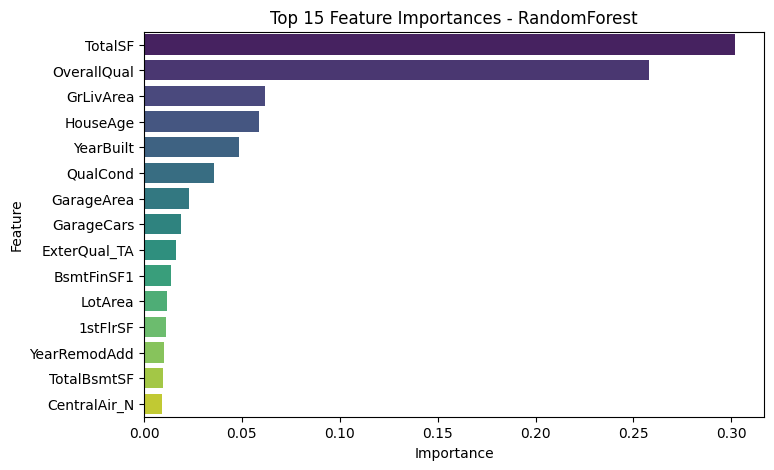

2025/10/28 16:33:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


💾 Model đã được lưu tại: experiments/models\RandomForest_best.pkl
✅ Mô hình đã lưu local: experiments/models\RandomForest_regression_best_163254_20251028_163309_model.pkl


2025/10/28 16:33:13 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Dữ liệu đã lưu local: experiments/data/processed\RandomForest_regression_best_163254_20251028_163313_data.csv


In [81]:
from pipeline.RFPipline import RFPipeline
pipeline = RFPipeline(experiment_name="version3")
pipeline.run(
    df=train,
    target_col=target,
    task="regression",
    model_name="RandomForest",
    backend="mlflow"
)

In [82]:
import joblib
model_da_load = joblib.load('experiments/models/XGBoost_regression_best_163110_20251028_163137_model.pkl')
Xgb_preds = model_da_load.predict(test)
y_log_preds = np.expm1(Xgb_preds)
submission= pd.DataFrame({'Id': test.Id,'SalePrice':y_log_preds })
submission.to_csv('submission.csv',index=False)

In [83]:
import joblib
cat = joblib.load('experiments/models/CatBoost_regression_best_163142_20251028_163210_model.pkl')
xgb = joblib.load('experiments/models/XGBoost_regression_best_163110_20251028_163137_model.pkl')
predict4 = cat.predict(test)
cat = np.expm1(predict4)
predict3 = xgb.predict(test)
XG = np.expm1(predict3)
predict_y = ( XG*0.45 + cat * 0.55)
submission= pd.DataFrame({'Id': test.Id,'SalePrice': predict_y})
submission.to_csv('submission.csv',index=False)